# Homework 4<a class="anchor" id="section_homework"></a>

**Feladat:**: <br>

Background: In the Black--Scholes model volatility is a key parameter that determines option price. In a Balanced Binomial Tree (i.e. risk-neutral up step probability 
 risk-neutral down step probability 
) the same role is played by step size: higher step is like higher volatility, it results in higher option prices. Also, there is a 1-1 correspondence between step size and price if all other parameters are fixed.


Task: Write a calibrate method which, for a given number of steps parameter, computes the up step size for which a Balanced Binomial Tree model returns the specified price for a given European call. (In practice option prices can be observed in the market, so it makes sense to assume it is given). Demonstrate the calibrate method for various input parameters (same contract with a few different number of steps (dont forget to scale the discount factor to keep interest rates flat); calibrate one step tree for various contracts (different expiries and strike levels, flat interest rate)). Make simple plots to illustrate results.


Hint: To do it you will need to use a root solver, I recommend using scipy.optimize.minimize.

**Megoldás**: <br>

***1, Black-Scholes árazó***

Először is az előző háziból kicopyztam a BS pricer függvényt, hogy legyen valami "valódi" opciós árunk.

In [1]:
from typing import Union, List
import numpy as np
from scipy.stats import norm


def black_scholes_eur_call(
    r: float,
    T: float,
    S0: float,
    sigma: float,
    K: Union[float, List[float], np.ndarray],
):
    """
    Black-Scholes pricer of European call option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param 
    """
    #check conditions
    assert sigma > 0

    K_vec = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = (np.log(S0 / K_vec) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_vec = d1_vec - sigma * np.sqrt(T)

    
    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)
    n_d1_vec = norm.pdf(d1_vec)  #sűrűségfüggvény ()

    #PRICE
    price = N_d1_vec*S0 - K_vec * np.exp((-1.0)*r*T) * N_d2_vec

    #GREEKS
    delta = N_d1_vec

    gamma = n_d1_vec / (S0 * sigma * np.sqrt(T))

    vega = S0 * n_d1_vec * np.sqrt(T)

    theta = (
        -S0 * n_d1_vec * sigma / (2 * np.sqrt(T))
        - r * K_vec * np.exp(-r * T) * N_d2_vec
    )

    rho = K_vec * T * np.exp(-r * T) * N_d2_vec

    # dictionary a return
    return {
        "price": price,
        "delta": delta,
        "gamma": gamma,
        "vega": vega,
        "theta": theta,
        "rho": rho,
    }

Legyenek alap paramétereink, amivel először teszteljük, hogy működnek-e a dolgok

In [2]:
spot=100   
r=0.05   #logkamatláb
sigma=0.3
K=110
T=1

In [3]:
call=black_scholes_eur_call(r, T, spot, sigma, K)
call["price"]

10.02007762005595

**Spot and price tree**

Most pedig az órán bemutatott kódot lecopyztam, hogy legyen egy binomiális pricer.

In [4]:
def create_spot_tree(spot: float, spot_mult_up: float, spot_mult_down: float, steps: int) -> list[list[float]]:
    previous_level = [spot]
    tree = [previous_level]
    for _ in range(steps):
        new_level = [s * spot_mult_down for s in previous_level]
        new_level += [previous_level[-1] * spot_mult_up]
        tree += [new_level]
        previous_level = new_level
    return tree

In [5]:
spot = 100
spot_mult_up = 1.2
spot_mult_down = 0.8
steps = 2
spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down, steps)
spot_tree_readable = [['%.3f' % e for e in n] for n in spot_tree]
spot_tree_readable

[['100.000'], ['80.000', '120.000'], ['64.000', '96.000', '144.000']]

In [6]:
def european_call_payoff(S: float, K: float) -> float:
    return max(S-K, 0.0)

In [7]:
def create_discounted_price_tree(spot_tree: list[list[float]], discount_factor: float, K: float, diag: int = 0) -> list[list[float]]:
    spot = spot_tree[0][0]
    spot_mult_up = spot_tree[1][-1]/spot    #kijavítva
    spot_mult_down = spot_tree[1][0]/spot    #ez is spottal osztani kell
    p_up = ((1 / discount_factor - spot_mult_down) /
                   (spot_mult_up - spot_mult_down))
    p_down = 1 - p_up
    steps = len(spot_tree) - 1
    continuation_value_tree = [[np.nan for _ in level] for level in spot_tree]
    if diag > 0:
        print("risk-neutral measure: ")
        print(('%.3f' % p_up, '%.3f' % p_down))
        # init delta tree
        delta_tree = [[np.nan for _ in level] for level in spot_tree[:-1]] #delta makes no sense for leaves
    # going backwards, payoff is known in leaves
    for i in range(len(spot_tree[-1])):
        spot = spot_tree[-1][i]
        discounted_continuation_value = discount_factor**(steps) * european_call_payoff(spot, K)
        continuation_value_tree[-1][i] = discounted_continuation_value
    for step in range(steps - 1, -1, -1):
        for i in range(len(spot_tree[step])):
            continuation_value_tree[step][i] = p_up * continuation_value_tree[step + 1][i] + \
                                            p_down * continuation_value_tree[step + 1][i + 1]
        """ if diag > 0:
                delta_tree[step][i] = ((continuation_value_tree[step + 1][i] - continuation_value_tree[step + 1][i + 1]) 
                                       / (spot_tree[step + 1][i] - spot_tree[step + 1][i + 1]))
    if diag > 0:
        print("delta: ")
        delta_tree_readable = [['%.3f' % e for e in n] for n in delta_tree]
        print(delta_tree_readable)"""        #kivettem a delta treet
    return continuation_value_tree

In [9]:
dt=T/steps
discount_factor = np.exp(-r*dt)  #egyelőre csak 1 év
strike = K
diag = 1
price_tree = create_discounted_price_tree(spot_tree, discount_factor, strike, diag)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("Price tree:")
price_tree_readable

risk-neutral measure: 
('0.563', '0.437')
Price tree:


[['6.168'], ['0.000', '14.124'], ['0.000', '0.000', '32.342']]

Nekünk majd balanced tree kell, ehhez úgy kell megválasztani d-t, hogy a kockázatesemleges mérték 0.5 legyen.
Erre szintén szerepelt képlet az órai kódban.


In [10]:
def calcBalancedDownStep(spot_mult_up, discount_factor):
    return spot_mult_up - 2 * (spot_mult_up - 1 / discount_factor)

Most picit összesítve az előzőeket itt van egy jobban átlátható példa egy opció beárazására a binomiális fával előre megadott u-val

In [11]:
T=1
r=0.05
steps=10
dt=T/steps
spot = 100
discount_factor = np.exp(-r*dt)  #feltételezzük, hogy r logkamatláb, ami BS inputja
strike = K
diag = 1

spot_mult_up = 1.2
spot_mult_down = calcBalancedDownStep(spot_mult_up, discount_factor)

spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down, steps)

price_tree = create_discounted_price_tree(spot_tree, discount_factor, strike, diag)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("Price tree:")
price_tree[0]

risk-neutral measure: 
('0.500', '0.500')
Price tree:


[23.115325127533545]

**u kalibrálása az árból**

Először írtam egy függvényt, aminek az egyik bemeneti paramétere u, hogy ezt lehessen majd optimalizálni és kalibrálni az árhoz. Ez egyből visszaadja a 
binomiális modell alapján az árat.

In [12]:
def price_from_u(u, spot, K, r, T, steps):
    
    dt = T/steps
    D = np.exp(-r*dt)
    
    d = calcBalancedDownStep(u, D)
    
    spot_tree = create_spot_tree(spot, u, d, steps)
    
    price_tree = create_discounted_price_tree(
        spot_tree,
        D,
        K,
        diag=0
    )
    
    return price_tree[0][0]

In [13]:
#teszt 
price_from_u(spot_mult_up,spot, K, r, T, steps)

23.115325127533545

Most pedig akkor olyan u-t kell keresni, amivel visszakapjuk adott lépésszámra a tényleges opcióárat. Alapból a feladat a scipy függvényt említette optimum keresésre, 
de talán itt egyszerűbb a primitív felezgetős módszert használni. A lényeg az lesz, hogy a binomiális modell alapján kapott ár és a black scholes alapján kapott
ár köztti különbséget akarjuk minimalizálni. Legyen f a különbbségfüggvény és ugye ezt akarjuk, hogy 0-hoz minél közelebb legyen valamilyen u értékre. Általában az szokás
ilyen optimalizálásnál, hogy vagy egy előre rögzített iteráció után adja vissza az értéket, vagy ha elértünk egy megadott tolerancia szintet.

In [14]:
import numpy as np

def calibrate_u_bisection(price_from_u, market_price, spot, K, r, T, steps,
                          u_low=None, u_high=None, tol=1e-8, max_iter=200):


    dt = T / steps
    D = np.exp(-r * dt)

    # Balanced modellhez megengedett tartomány:
    # felső korlát a balance miatt: d > 0 és d = 2/D - u  => u < 2/D
    # alsó korlát az arbitrázsmentességhez: 1/D<u
    if u_low is None:
        u_low = 1.0 + 1e-6
    if u_high is None:
        u_high = 2.0 / D - 1e-6

    def f(u):  
        return price_from_u(u, spot, K, r, T, steps) - market_price

    f_low = f(u_low)
    f_high = f(u_high)


    # kell előjelváltás
    if f_low * f_high > 0:   #itt is teszteljük az elején, hogy egyáltalán a megoldás a lehetséges kezdeti intervallumban benne van e
        raise ValueError(
            "A megoldás nincs a megadott intervallumban.\n"
            f"f(u_low)={f_low}, f(u_high)={f_high}. "
        )

    for i in range(max_iter):
        u_mid = 0.5 * (u_low + u_high)  #számoljuk ki a közepet
        f_mid = f(u_mid)   #itt határozzuk meg az eltérést

        if abs(f_mid) < tol:  #ha kisebb, mint a toleranica, akkor készen vagyunk
            return u_mid

        # ha nem, akkor pedig nézzük meg, hogy melyik "félintervallumban" lesz a gyök, amit keresünk.
        if f_low * f_mid <= 0:   #ha ez teljesül, akkor a [low,mid] intervallumban lesz előjelváltás, vagyis van gyök (folytonos függvénynél)
            u_high, f_high = u_mid, f_mid
        else:
            u_low, f_low = u_mid, f_mid

    return 0.5 * (u_low + u_high)

In [23]:
spot=100
K=110
r=0.05
sigma=0.3
T=1
steps=10


call=black_scholes_eur_call(r, T, spot, sigma, K)
market_price = call["price"]
u_star = calibrate_u_bisection(price_from_u, market_price, spot, K, r, T, steps)
print("u* =", u_star)
print("BS price =", market_price)
print("model price =", price_from_u(u_star, spot, K, r, T, steps))

u* = 1.0979520538646077
BS price = 10.02007762005595
model price = 10.020077611301305


**Ábrák**

Még azt vizsgáltam, hogyan változik az u és d, ha változtatjuk a különböző paramétereket.

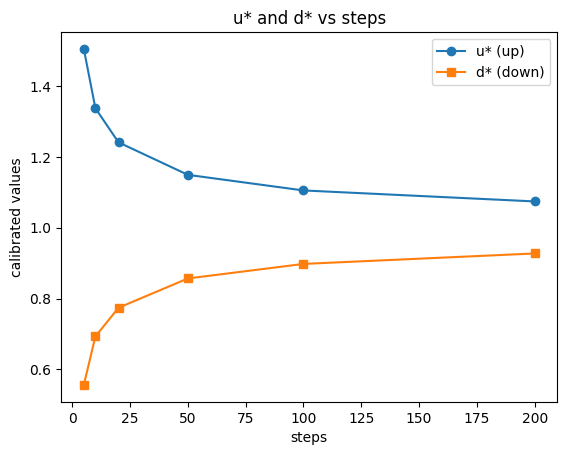

In [32]:
import matplotlib.pyplot as plt

dt = T/steps
D = np.exp(-r*dt)
    
d = calcBalancedDownStep(u_star, D)

steps_list = [5,10,20,50,100,200]

u_list = []
d_list = []

for N in steps_list:
    u_star = calibrate_u_bisection(price_from_u, market_price, spot, K, r, T, N)
    u_list.append(u_star)

    dt = T/N
    D = np.exp(-r*dt)
    d_star = calcBalancedDownStep(u_star, D)
    d_list.append(d_star)

plt.plot(steps_list, u_list, marker="o", label="u* (up)")
plt.plot(steps_list, d_list, marker="s", label="d* (down)")
plt.xlabel("steps")
plt.ylabel("calibrated values")
plt.title("u* and d* vs steps")
plt.legend()
plt.show()

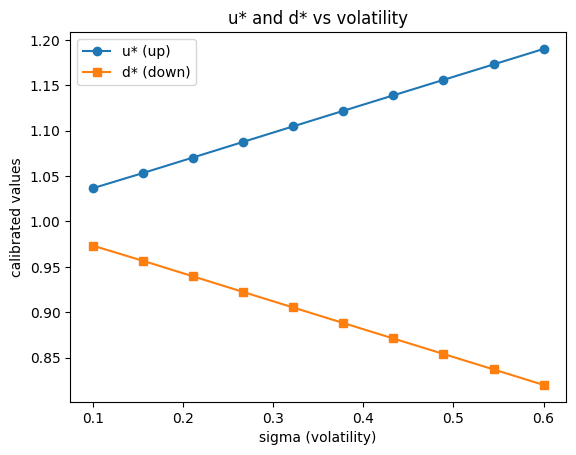

In [30]:
sigma_list = np.linspace(0.1, 0.6, 10)

u_list = []
d_list = [] # 1. Létrehozzuk a listát a d* értékeknek

for sigma in sigma_list:
    call = black_scholes_eur_call(r, T, spot, sigma, K)
    market_price = call["price"]
    
    u_star = calibrate_u_bisection(price_from_u, market_price, spot, K, r, T, steps)
    u_list.append(u_star)
    
    # 2. Kiszámoljuk a d* értéket (az előző kódod alapján a D-t r és dt-ből számoljuk)
    dt = T / steps
    D = np.exp(-r * dt)
    d_star = calcBalancedDownStep(u_star, D)
    d_list.append(d_star)

# 3. Megjelenítés
plt.plot(sigma_list, u_list, marker="o", label="u* (up)")
plt.plot(sigma_list, d_list, marker="s", label="d* (down)")

plt.xlabel("sigma (volatility)")
plt.ylabel("calibrated values")
plt.title("u* and d* vs volatility")
plt.legend() # Hogy látszódjon melyik melyik
plt.show()

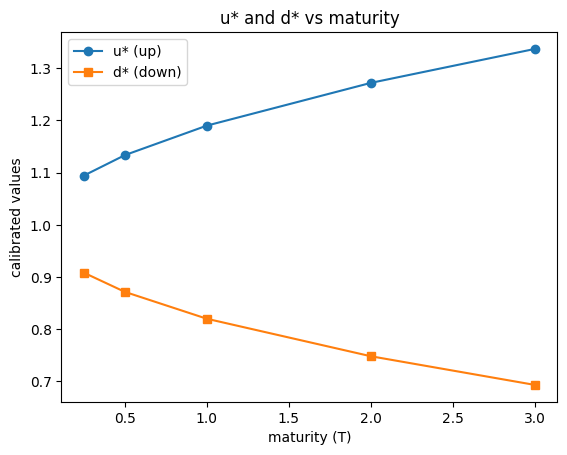

In [31]:
T_list = [0.25, 0.5, 1, 2, 3]

u_list = []
d_list = [] # 1. Lista a d* értékeknek

for T in T_list:
    call = black_scholes_eur_call(r, T, spot, sigma, K)
    market_price = call["price"]
    
    u_star = calibrate_u_bisection(price_from_u, market_price, spot, K, r, T, steps)
    u_list.append(u_star)
    
    # 2. Kiszámoljuk a d* értéket az adott T-hez tartozó dt-vel
    dt = T / steps
    D = np.exp(-r * dt)
    d_star = calcBalancedDownStep(u_star, D)
    d_list.append(d_star)

# 3. Megjelenítés
plt.plot(T_list, u_list, marker="o", label="u* (up)")
plt.plot(T_list, d_list, marker="s", label="d* (down)")

plt.xlabel("maturity (T)")
plt.ylabel("calibrated values")
plt.title("u* and d* vs maturity")
plt.legend()
plt.show()